<a href="https://colab.research.google.com/github/anaskmh/pythonminiproject/blob/main/mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [155]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [190]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print(mnist)
# print(x_train)
# print(x_test)

<module 'keras.datasets.mnist' from '/usr/local/lib/python3.12/dist-packages/keras/datasets/mnist/__init__.py'>


In [157]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [158]:
model = models.Sequential([
    layers.Flatten(input_shape=(28, 28)),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(10, activation="softmax")
    ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [159]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [160]:
model.fit(x_train, y_train, epochs=6, validation_data=(x_test, y_test))

Epoch 1/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9117 - loss: 0.3028 - val_accuracy: 0.9598 - val_loss: 0.1422
Epoch 2/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9571 - loss: 0.1467 - val_accuracy: 0.9688 - val_loss: 0.0993
Epoch 3/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9674 - loss: 0.1096 - val_accuracy: 0.9733 - val_loss: 0.0839
Epoch 4/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9725 - loss: 0.0890 - val_accuracy: 0.9747 - val_loss: 0.0769
Epoch 5/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9760 - loss: 0.0752 - val_accuracy: 0.9766 - val_loss: 0.0727
Epoch 6/6
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9793 - loss: 0.0659 - val_accuracy: 0.9772 - val_loss: 0.0747


In [161]:
model.save("nueral.keras")
print("Model saved as gt_nueral.keras")

Model saved as gt_nueral.keras


In [162]:
loaded_model = tf.keras.models.load_model("nueral.keras")
print("Model loaded from gt_nueral.keras")

Model loaded from gt_nueral.keras


In [163]:
loaded_model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9772 - loss: 0.0747


[0.0746549442410469, 0.9771999716758728]

In [164]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [218]:
import numpy as np
predictions = loaded_model.predict(x_test)
print(np.argmax(predictions[2]))

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1


In [213]:
import numpy as np
predictions = loaded_model.predict(x_test)
position_number = 10
# Accessing the 7th item (index 6) from the predictions array
print(f"The predicted digit for the {position_number}th test image is: {np.argmax(predictions[position_number - 1])}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
The predicted digit for the 10th test image is: 9


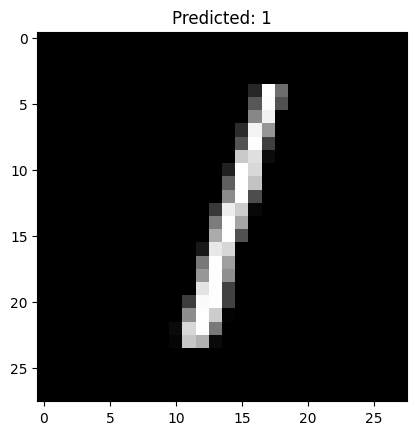

In [219]:
plt.imshow(x_test[2], cmap="gray")
plt.title(f"Predicted: {np.argmax(predictions[2])}")
plt.show()